# Wczytanie danych

In [1]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Dane/dane/domy_manchester.csv")
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,lad23cd,transactionid,lmk_key,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,CONSTRUCTION_AGE_BAND
0,1675.675676,2020,2020-04-20,T,F,186000,M19 3DB,E08000003,{A96E4ACC-3ECA-9205-E053-6C04A8C0DA09},1759278269922019101811263657988141,111.00,5.0,11,59,76,England and Wales: 1900-1929
1,1730.831446,2001,2001-09-07,F,L,107000,M1 1EP,E08000003,{E0085A37-16A8-46DD-9B26-8CCFA4B3EA91},160153540702008101321014155289678,61.82,3.0,11,69,71,England and Wales: 1996-2002
2,2224.199288,2016,2016-02-19,F,L,137500,M1 1EP,E08000003,{31FB4C17-4AC2-57B9-E050-A8C063053436},160153540702008101321014155289678,61.82,3.0,11,69,71,England and Wales: 1996-2002
3,420.902160,1999,1999-03-16,F,L,26500,M7 4QZ,E08000003,{6E0E237C-EEBB-41D9-88B9-0BC41EC1B54B},360154628152009090913550001010469,62.96,3.0,12,59,73,England and Wales: 1967-1975
4,786.213469,1997,1997-01-20,F,L,49500,M7 4QZ,E08000003,{76A5A6A7-61F4-48EA-B977-7A3D7D14D853},360154628152009090913550001010469,62.96,3.0,12,59,73,England and Wales: 1967-1975


In [2]:
data = data.drop(columns=['lad23cd','transactionid','lmk_key','CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY','CONSTRUCTION_AGE_BAND','classt'])

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181354 entries, 0 to 181353
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   priceper        181234 non-null  float64
 1   year            181354 non-null  int64  
 2   dateoftransfer  181354 non-null  object 
 3   propertytype    181354 non-null  object 
 4   duration        181354 non-null  object 
 5   price           181354 non-null  int64  
 6   postcode        181354 non-null  object 
 7   tfarea          181354 non-null  float64
 8   numberrooms     165515 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 12.5+ MB


In [4]:
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms
0,1675.675676,2020,2020-04-20,T,F,186000,M19 3DB,111.00,5.0
1,1730.831446,2001,2001-09-07,F,L,107000,M1 1EP,61.82,3.0
2,2224.199288,2016,2016-02-19,F,L,137500,M1 1EP,61.82,3.0
3,420.902160,1999,1999-03-16,F,L,26500,M7 4QZ,62.96,3.0
4,786.213469,1997,1997-01-20,F,L,49500,M7 4QZ,62.96,3.0


# Brakujące wartości

In [5]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [6]:
missing_data[:4]

,missing value,percentage
numberrooms,15839,8.733747
priceper,120,0.066169
year,0,0.000000
propertytype,0,0.000000


In [7]:
data['numberrooms'] = data['numberrooms'].fillna(data['numberrooms'].median())

In [8]:
data = data[data['priceper'].notna()]

# Wartości odstające

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
priceper,181234.0,1811.829686,1202.797750,1.977612,903.614458,1666.666667,2492.307692,5.555556e+04
year,181234.0,2008.973454,7.944617,1995.000000,2003.000000,2007.000000,2016.000000,2.024000e+03
price,181234.0,142624.308386,113752.596651,265.000000,69000.000000,123000.000000,182000.000000,4.500000e+06
tfarea,181234.0,81.676034,33.881646,2.910000,62.000000,75.000000,93.000000,1.521550e+03
numberrooms,181234.0,4.147108,1.445962,1.000000,3.000000,4.000000,5.000000,5.500000e+01


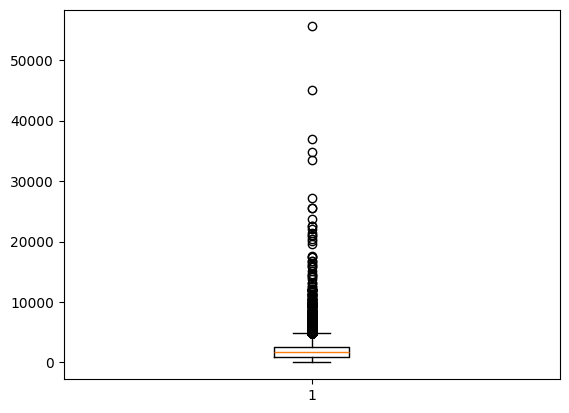

In [10]:
import matplotlib.pyplot as plt
plt.boxplot(x=data['priceper'])
plt.show()

In [11]:
import numpy as np
q1 = np.quantile(data['numberrooms'], 0.25)
q3 = np.quantile(data['numberrooms'], 0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [12]:
outliers_1 = data[(data['numberrooms'] > upper_lim) | (data['numberrooms'] < lower_lim)]
outliers_1

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms
4553,1398.416887,2005,2005-02-25,D,L,106000,M9 8QA,75.80,45.0
41951,4141.414141,2017,2017-06-12,T,F,410000,M21 8DD,99.00,55.0
41952,3333.333333,2015,2015-06-05,T,F,330000,M21 8DD,99.00,55.0
61221,3716.216216,2021,2021-12-13,D,F,1650000,M20 6DB,444.00,16.0
78438,621.794872,2002,2002-08-19,T,L,48500,M14 7PT,78.00,41.0
78439,2147.435897,2021,2021-10-15,T,L,167500,M14 7PT,78.00,41.0
78440,473.717949,2000,2000-08-25,T,L,36950,M14 7PT,78.00,41.0
83017,648.648649,1995,1995-09-08,T,L,48000,M23 9PN,74.00,41.0
83018,3331.081081,2022,2022-08-31,T,F,246500,M23 9PN,74.00,41.0
83019,662.162162,1998,1998-06-12,T,L,49000,M23 9PN,74.00,41.0


In [13]:
data = data[~((data['numberrooms'] > upper_lim) | (data['numberrooms'] < lower_lim))]

# Kody pocztowe -> dzielnice

In [14]:
pc = pd.read_csv("/content/drive/MyDrive/Dane/dane/M postcodes.csv")
pc.head()

,Postcode,In Use?,Latitude,Longitude,Easting,Northing,Grid Ref,County,District,Ward,...,MSOA21 Code,Middle layer super output area 2021,Census output area 2021,IMD decile,Constituency Code 2024,Constituency Name 2024,Property Type,Roads,FixPhrase,Rural/urban 2021
0,M1 1AD,Yes,53.483829,-2.244852,383849.0,398596.0,SJ838985,Greater Manchester,Manchester,Deansgate,...,E02006902,City Centre North & Collyhurst,E00175827,4.0,E14001352,Manchester Central,NaN,NaN,crowd lustrous strut varied,Urban: Nearer to a major town or city
1,M1 1AE,Yes,53.483487,-2.231182,384756.0,398555.0,SJ847985,Greater Manchester,Manchester,Piccadilly,...,E02006912,Piccadilly & Ancoats,E00176052,4.0,E14001352,Manchester Central,Flat,"Little Lever Street,Newton Street",crowd lustrous stubbed unmapped,Urban: Nearer to a major town or city
2,M1 1AF,Yes,53.480563,-2.237148,384359.0,398231.0,SJ843982,Greater Manchester,Manchester,Piccadilly,...,E02006912,Piccadilly & Ancoats,E00175961,3.0,E14001352,Manchester Central,NaN,Lever Street,crowd lustrous streak unranked,Urban: Nearer to a major town or city
3,M1 1AJ,Yes,53.483009,-2.232264,384684.0,398502.0,SJ846985,Greater Manchester,Manchester,Piccadilly,...,E02006912,Piccadilly & Ancoats,E00175823,4.0,E14001352,Manchester Central,NaN,NaN,crowd lustrous stubbed tarnish,Urban: Nearer to a major town or city
4,M1 1AL,Yes,53.483183,-2.230472,384803.0,398521.0,SJ848985,Greater Manchester,Manchester,Piccadilly,...,E02006912,Piccadilly & Ancoats,E00180885,4.0,E14001352,Manchester Central,Flat,"Houldsworth Street,Newton Street",crowd lustrous stubbed trustee,Urban: Nearer to a major town or city


In [15]:
data['neighbourhood'] = data['postcode'].map(pc.set_index('Postcode')['Ward'])

In [16]:
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms,neighbourhood
0,1675.675676,2020,2020-04-20,T,F,186000,M19 3DB,111.00,5.0,Levenshulme
1,1730.831446,2001,2001-09-07,F,L,107000,M1 1EP,61.82,3.0,Piccadilly
2,2224.199288,2016,2016-02-19,F,L,137500,M1 1EP,61.82,3.0,Piccadilly
3,420.902160,1999,1999-03-16,F,L,26500,M7 4QZ,62.96,3.0,Crumpsall
4,786.213469,1997,1997-01-20,F,L,49500,M7 4QZ,62.96,3.0,Crumpsall


# Konwersja typów

In [17]:
data['propertytype'] = data['propertytype'].str.replace('D', 'Wolnostojący', regex=False)
data['propertytype'] = data['propertytype'].str.replace('S', 'Bliźniak', regex=False)
data['propertytype'] = data['propertytype'].str.replace('T', 'Szeregowy', regex=False)
data['propertytype'] = data['propertytype'].str.replace('F', 'Mieszkanie', regex=False)

In [18]:
data['propertytype'].head()

,propertytype
0,Szeregowy
1,Mieszkanie
2,Mieszkanie
3,Mieszkanie
4,Mieszkanie


In [19]:
data['duration'] = data['duration'].str.replace('F', 'Własność', regex=False)
data['duration'] = data['duration'].str.replace('L', 'Dzierżawa', regex=False)

In [20]:
data['neighbourhood'] = data['neighbourhood'].str.replace(' and ', ' & ', regex=False)

In [21]:
numeryczne = data.select_dtypes(include='number')
numeryczne.head()

,priceper,year,price,tfarea,numberrooms
0,1675.675676,2020,186000,111.00,5.0
1,1730.831446,2001,107000,61.82,3.0
2,2224.199288,2016,137500,61.82,3.0
3,420.902160,1999,26500,62.96,3.0
4,786.213469,1997,49500,62.96,3.0


In [22]:
for col in numeryczne:
  data[col] = data[col].astype(str)
  data[col] = data[col].str.replace('.', ',', regex=False)

# Zapisanie

Wybierz dane po 2016

In [24]:
data = data[data['year'] >= '2016']

In [25]:
data['year'].unique()

array(['2020', '2016', '2021', '2017', '2022', '2023', '2018', '2019',
       '2024'], dtype=object)

In [26]:
data.to_csv('manchester_houses_cleaned.csv', index=False)